In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

RUNS_ROOT = '../Runs'

yolo_models = {
    'Quadrant Detection (Stage 1)': os.path.join(RUNS_ROOT, 'Stage 1', 'results.csv'),
    'Enumeration Detection (Stage 2)': os.path.join(RUNS_ROOT, 'Stage 2', 'results.csv'),
    'Enumeration Continued (Stage 2 Continued)': os.path.join(RUNS_ROOT, 'Stage 2 Continued', 'results.csv'),
}

yolo_rows = {}
for name, path in yolo_models.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip() 
    last_row = df.iloc[-1]
    yolo_rows[name] = {
        'mAP50': last_row.get('metrics/mAP50(B)'),
        'mAP50-95': last_row.get('metrics/mAP50-95(B)'),
        'precision': last_row.get('metrics/precision(B)'),
        'recall': last_row.get('metrics/recall(B)'),
    }

yolo_summary_df = pd.DataFrame(yolo_rows).T
yolo_summary_df

,mAP50,mAP50-95,precision,recall
Quadrant Detection (Stage 1),0.99500,0.72087,0.99879,0.99568
Enumeration Detection (Stage 2),0.92942,0.56098,0.93218,0.92044
Enumeration Continued (Stage 2 Continued),0.97856,0.78198,0.97093,0.95918


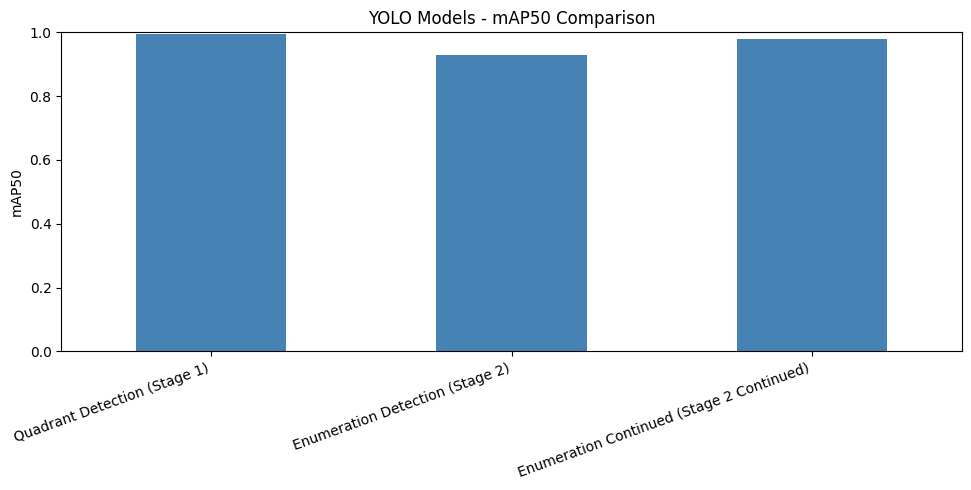

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
yolo_summary_df['mAP50'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('mAP50')
ax.set_title('YOLO Models - mAP50 Comparison')
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../Runs/yolo_models_comparison.png', dpi=150)
plt.show()

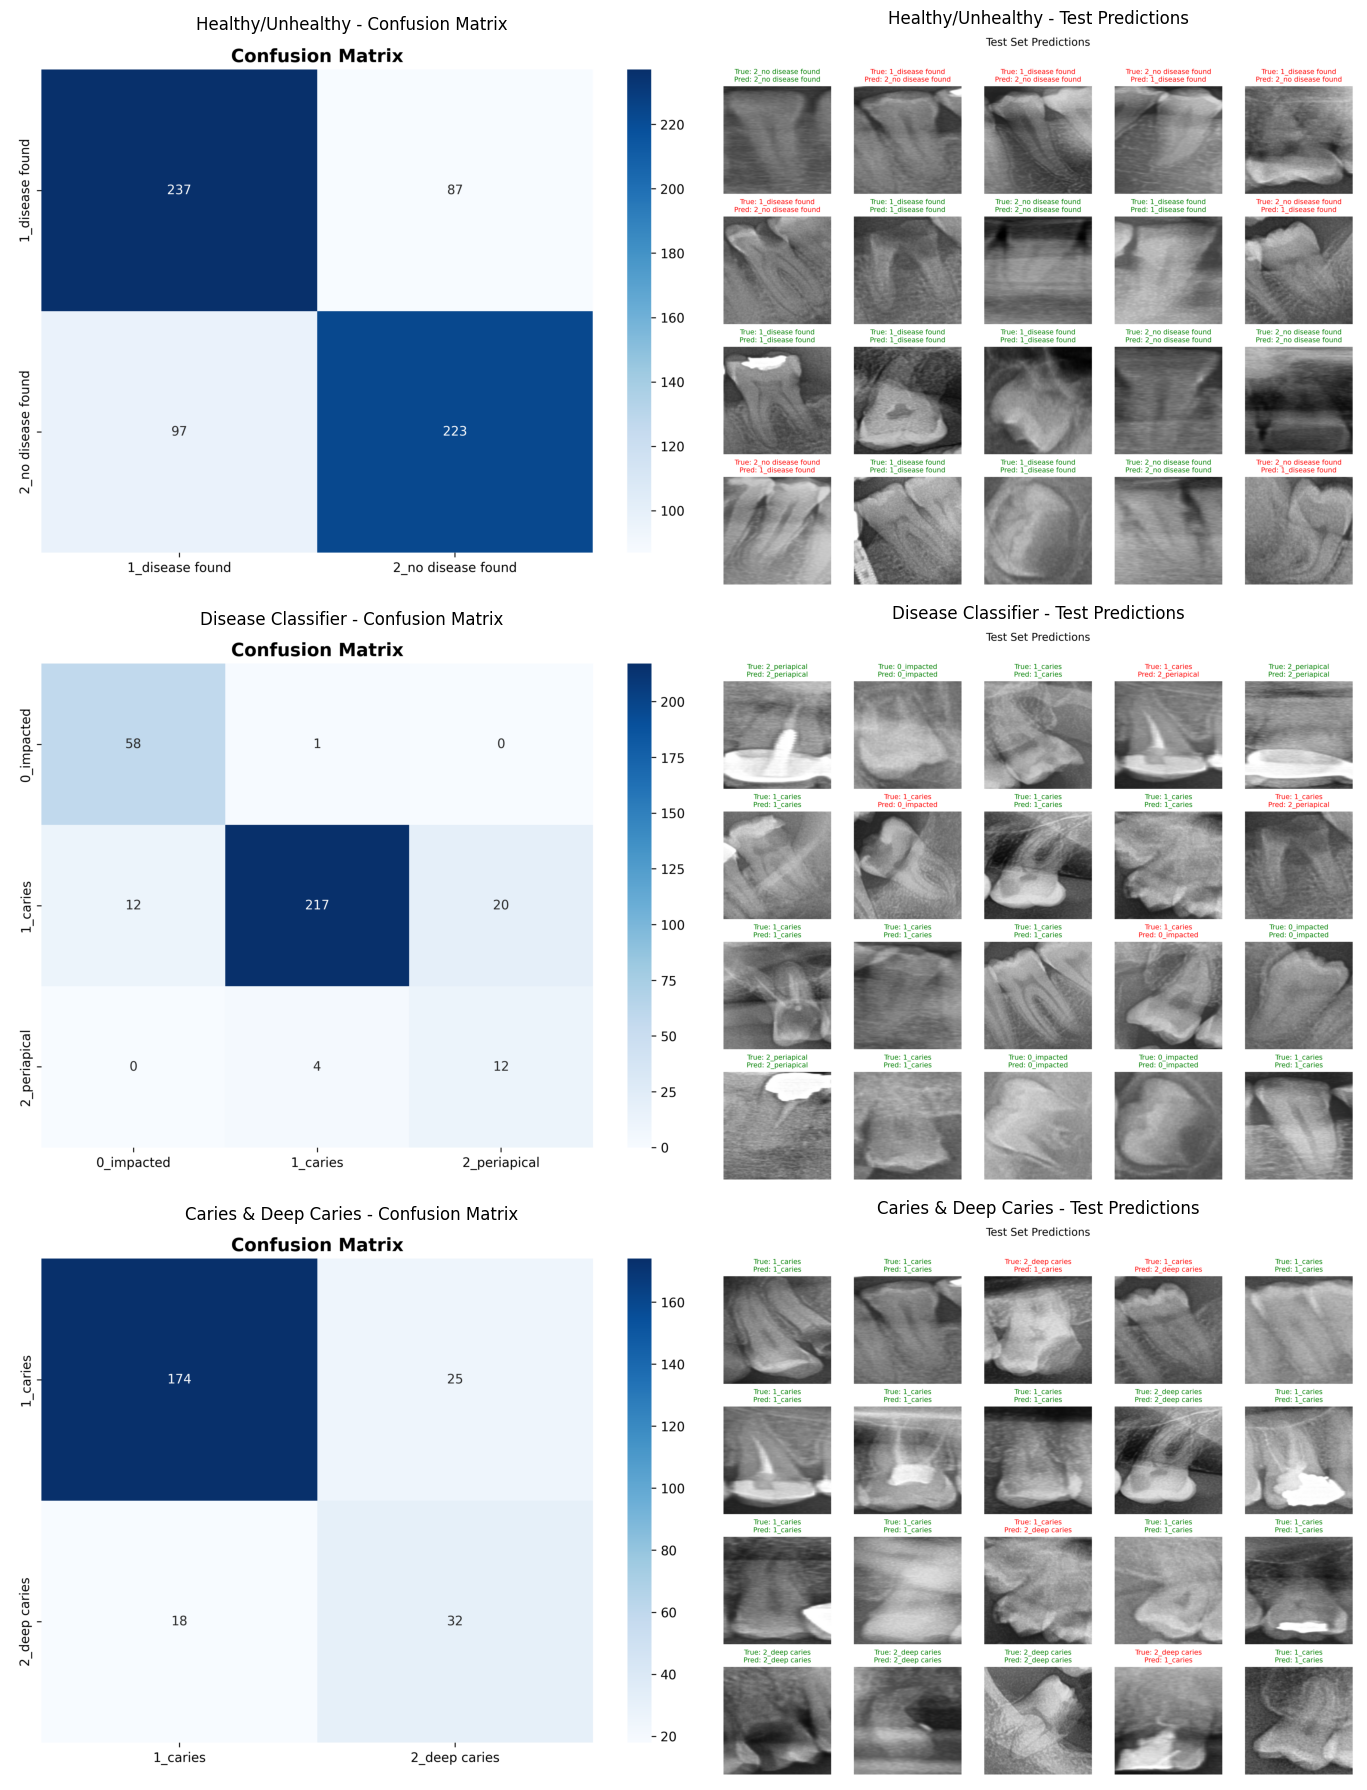

In [ ]:
classifiers = {
    'Healthy/Unhealthy': os.path.join(RUNS_ROOT, 'Stage 3', 'Healthy & Un-Healthy Classifier'),
    'Disease Classifier': os.path.join(RUNS_ROOT, 'Stage 3', 'Disease Classifier'),
    'Caries & Deep Caries': os.path.join(RUNS_ROOT, 'Stage 3', 'Caries & Deep Caries Classifier'),
}

fig, axes = plt.subplots(len(classifiers), 2, figsize=(14, 6 * len(classifiers)))

for i, (name, path) in enumerate(classifiers.items()):
    cm_img = mpimg.imread(os.path.join(path, 'confusion_matrix.png'))
    pred_img = mpimg.imread(os.path.join(path, 'test_set_predicted.png'))

    axes[i, 0].imshow(cm_img); axes[i, 0].set_title(f'{name} - Confusion Matrix'); axes[i, 0].axis('off')
    axes[i, 1].imshow(pred_img); axes[i, 1].set_title(f'{name} - Test Predictions'); axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('../Runs/Stage 3/final_classifiers_summary.png', dpi=150, bbox_inches='tight')
plt.show()